# Tutorial 14: Indirect & Direct Collocation Optimal Control

This tutorial covers Continuous Thrust Guidance using **Indirect Methods** (Pontryagin's Minimum Principle) and **Direct Methods** (Direct Collocation) to solve low-thrust trajectory optimization problems.

---

## 1. Theory Prerequisite

### 1.1 Indirect Method (PMP)
Formulates the problem by augmenting the state $x$ with costates $\lambda$ and forming the Hamiltonian $H$. Necessary conditions for optimality require solving a **Boundary Value Problem (BVP)**:
$$\dot{x} = \frac{\partial H}{\partial \lambda}, \quad \dot{\lambda} = -\frac{\partial H}{\partial x}$$
With boundary conditions for state at $t_0$ and $t_f$.

### 1.2 Direct Collocation
Discretizes the trajectory into a series of $N$ nodes. States and controls at nodes are treated as optimization variables. Linear/Quad constraints enforce that the dynamics update rule holds (e.g., Trapezoidal rule).

- **Objective**: Minimize total control effort $\int ||u(t)||^2 dt \approx \sum ||u_i||^2$
- **Constraints**: $\dot{x} = f(x, u)$ enforced via algebraic transcription formulation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gnc_toolkit.guidance.continuous_thrust import indirect_optimal_guidance, direct_collocation_guidance

print("Imports successful.")

Imports successful.


## 2. Demonstration: Indirect Optimal Guidance (BVP)

We solve for a continuous thrust maneuver from position $r_0$ to $r_f$ with specified velocities in a given time.

Solving BVP (Indirect Method)... This might take a few seconds.
Optimal Solution Found!


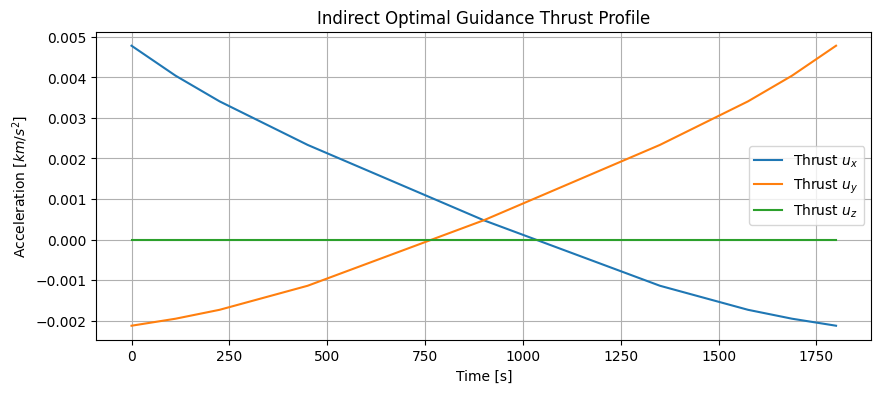

In [2]:
mu = 398600.4418
r0 = np.array([7000.0, 0.0, 0.0])
v0 = np.array([0.0, 7.5, 0.0])

rf = np.array([0.0, 7000.0, 0.0])
vf = np.array([-7.5, 0.0, 0.0])

tf = 1800.0  # 30 minutes transfer time

print("Solving BVP (Indirect Method)... This might take a few seconds.")
t_array, acc_profile = indirect_optimal_guidance(r0, v0, rf, vf, tf, mu)

if t_array is not None:
    print("Optimal Solution Found!")
    plt.figure(figsize=(10, 4))
    plt.plot(t_array, acc_profile[0, :], label='Thrust $u_x$')
    plt.plot(t_array, acc_profile[1, :], label='Thrust $u_y$')
    plt.plot(t_array, acc_profile[2, :], label='Thrust $u_z$')
    plt.xlabel('Time [s]')
    plt.ylabel('Acceleration [$km/s^2$]')
    plt.title('Indirect Optimal Guidance Thrust Profile')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Solver did not converge. Sensitivity to initial guess high (standard BVP issue).")

## 3. Demonstration: Direct Collocation Guidance

Direct methods aggregate state trajectories into large sparse formulations.

Solving Direct Collocation NLP...
Direct Collocation Solved!


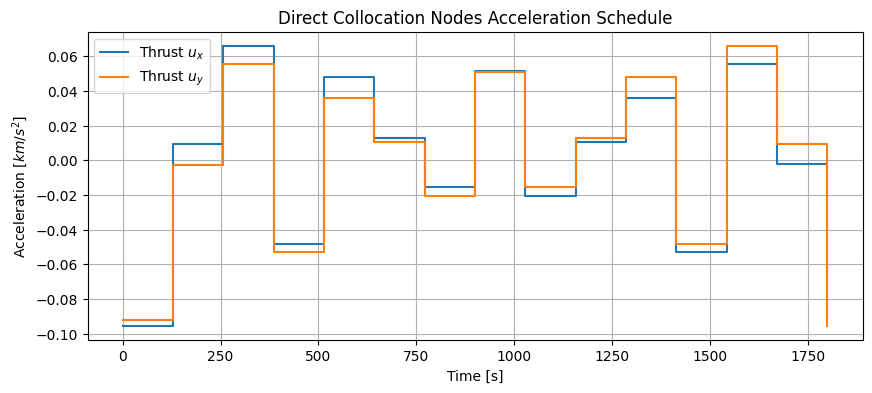

In [3]:
print("Solving Direct Collocation NLP...")
sol = direct_collocation_guidance(r0, v0, rf, vf, tf, mu, n_nodes=15)

if sol is not None:
    print("Direct Collocation Solved!")
    # sol shape: (n_nodes, 9) where state layout is [rx, ry, rz, vx, vy, vz, ax, ay, az]
    accs = sol[:, 6:9]
    time_colloc = np.linspace(0, tf, 15)
    
    plt.figure(figsize=(10, 4))
    plt.step(time_colloc, accs[:, 0], where='post', label='Thrust $u_x$')
    plt.step(time_colloc, accs[:, 1], where='post', label='Thrust $u_y$')
    plt.xlabel('Time [s]')
    plt.ylabel('Acceleration [$km/s^2$]')
    plt.title('Direct Collocation Nodes Acceleration Schedule')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Direct Collocation Solver failed to find feasible point.")